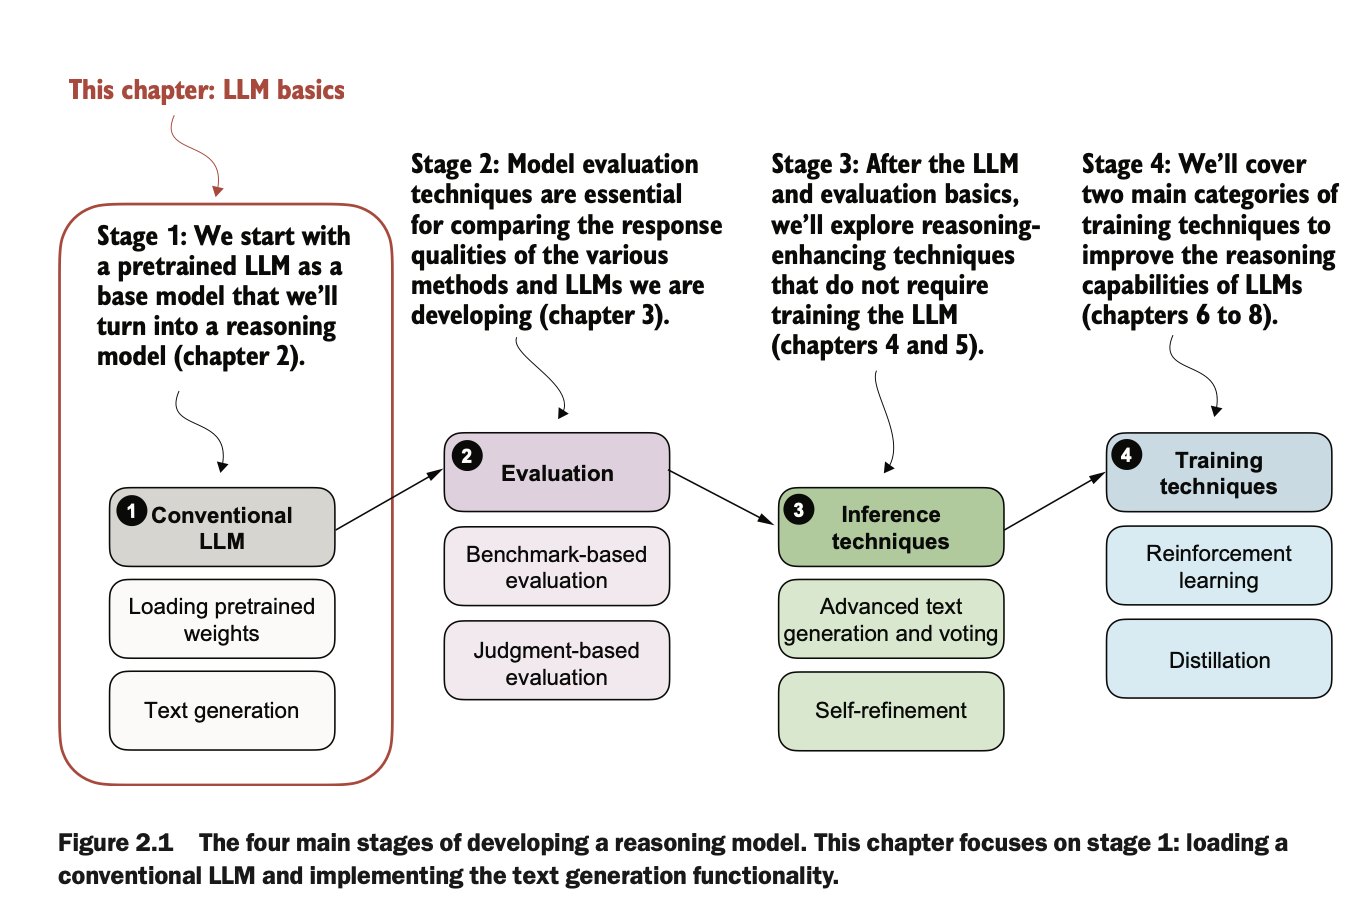


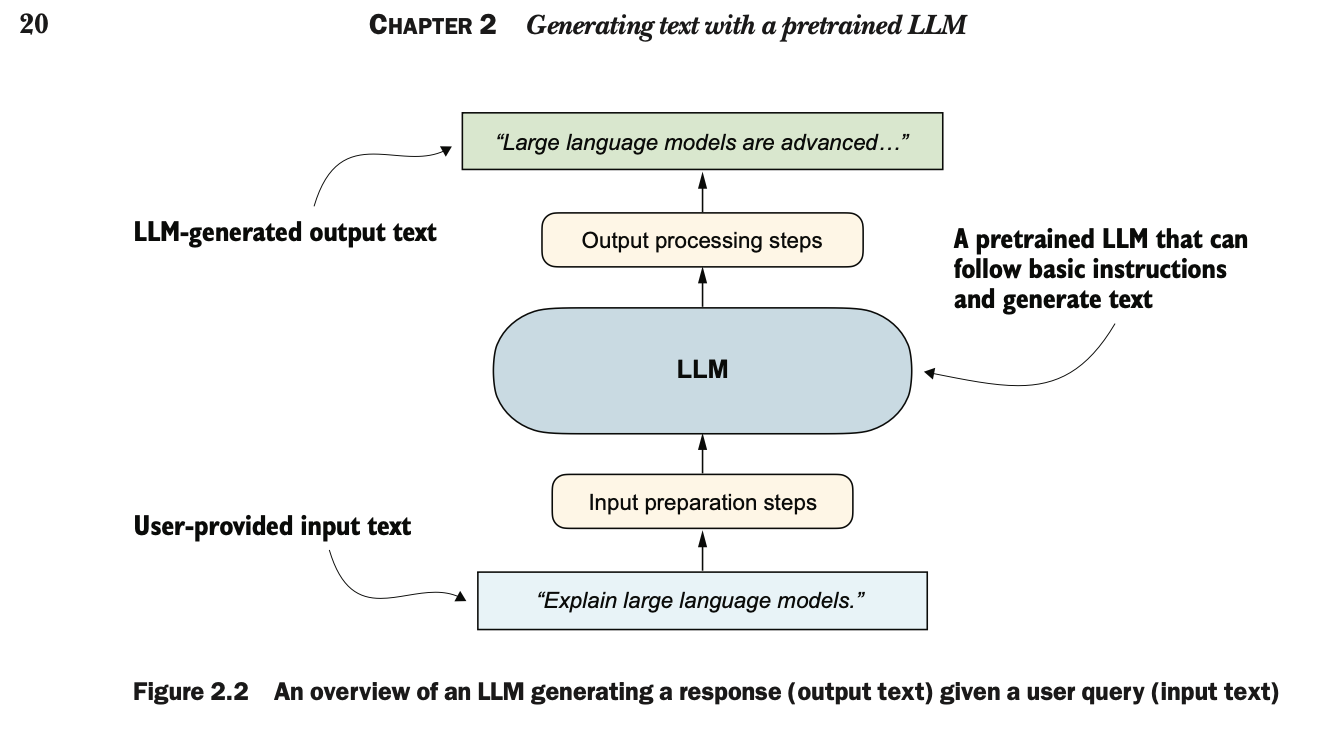


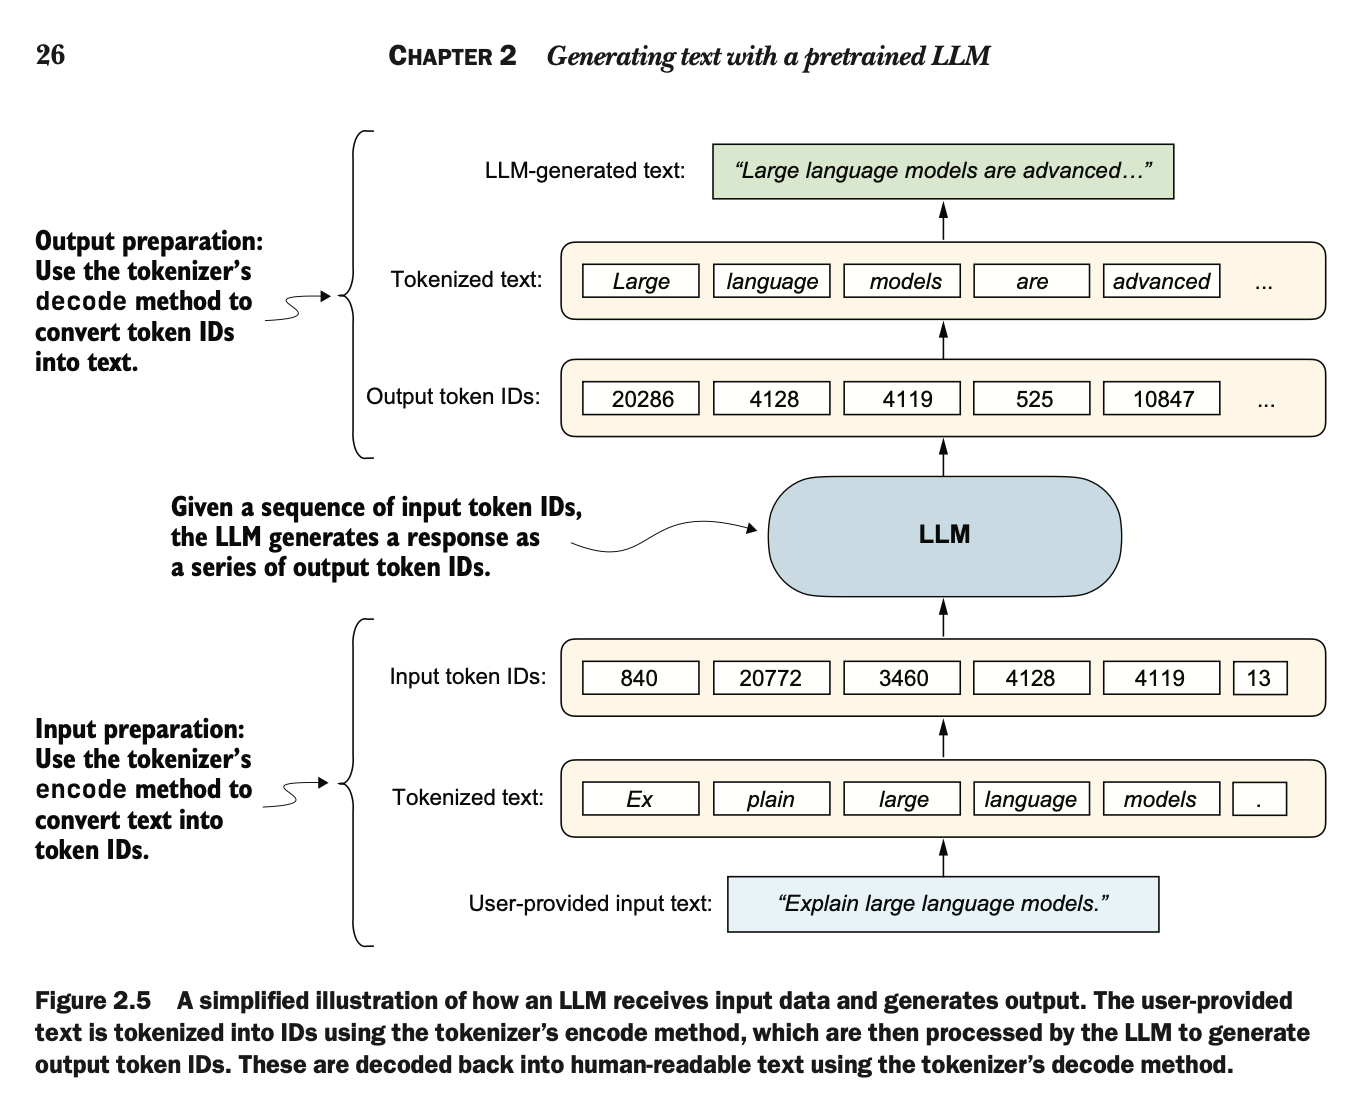


In [31]:
from reasoning_from_scratch.qwen3 import download_qwen3_small

download_qwen3_small(kind="base", tokenizer_only=True, out_dir="qwen3")

In [32]:
# Now, we can load the tokenizer settings from
# the tokenizer file into the Qwen3Tokenizer:
from pathlib import Path
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer

tokenizer_path = Path("qwen3") / "tokenizer-base.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)  # type: ignore

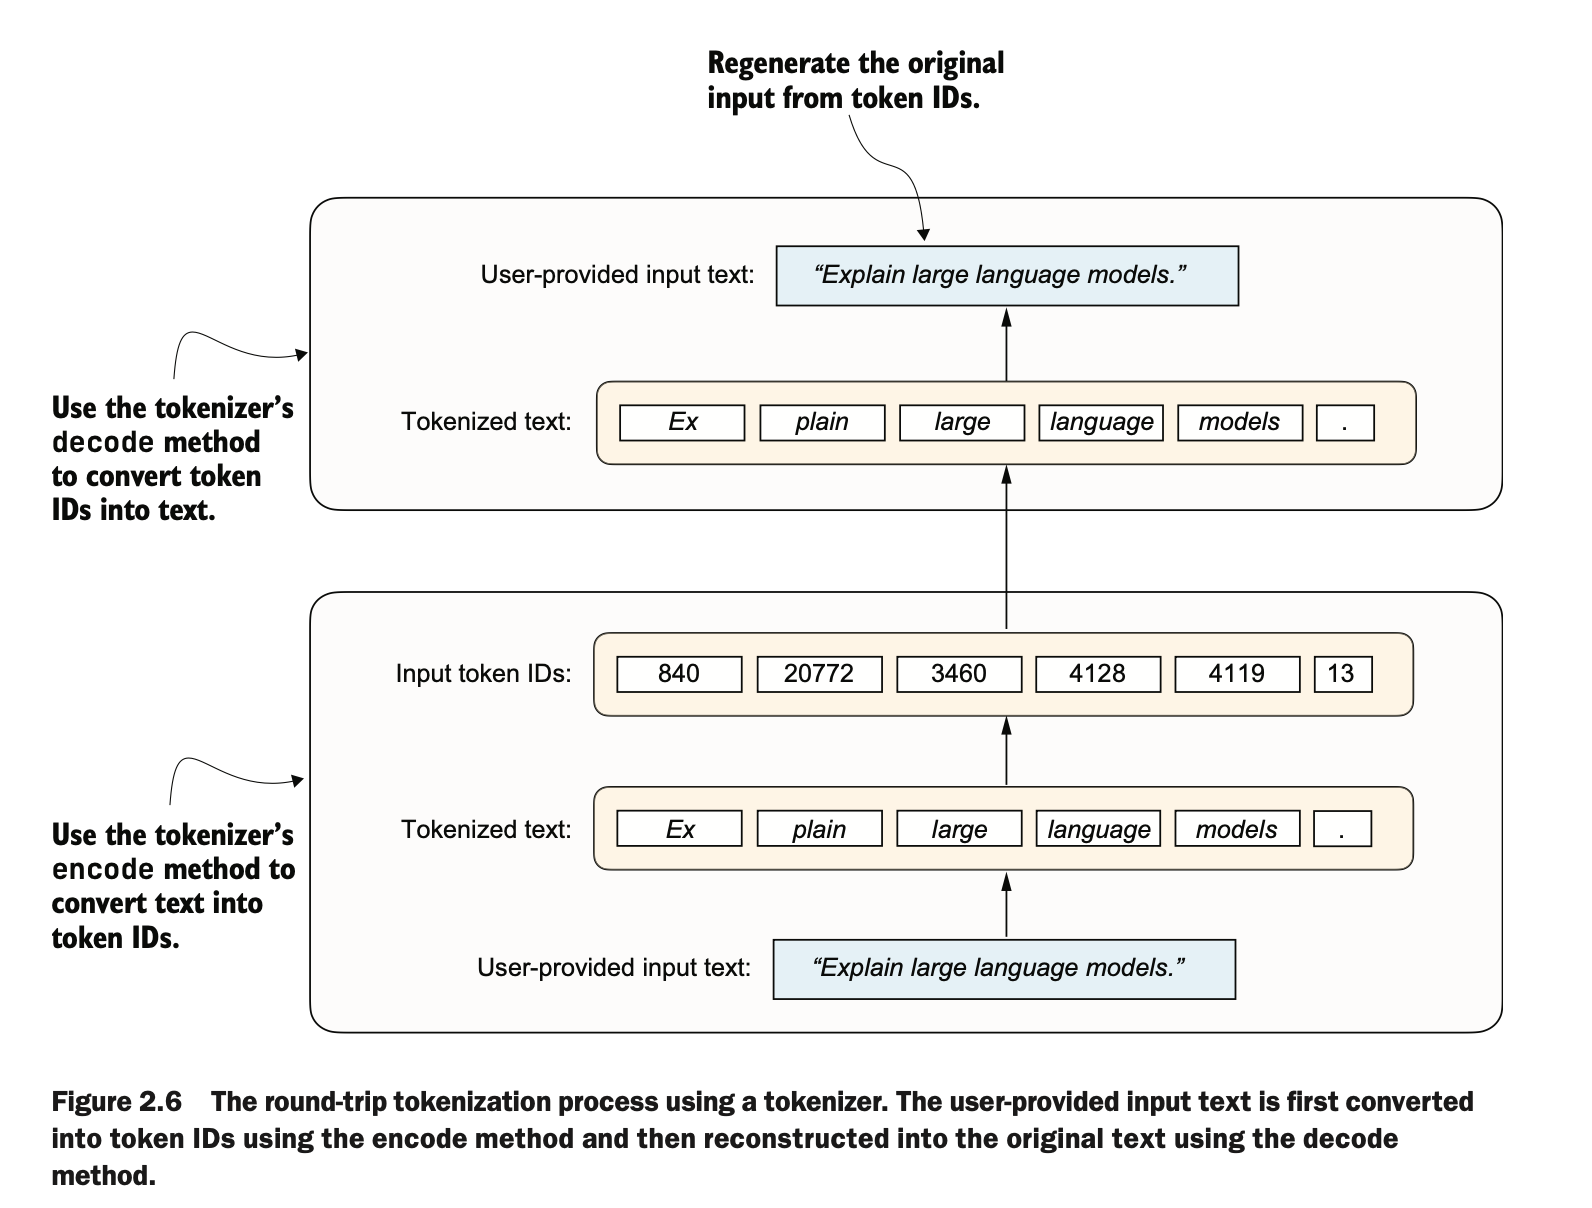


In [33]:
#  implements the encoding process shown in Figure 2.6

prompt = "Explain large language models."
input_token_ids_list = tokenizer.encode(prompt)
print(input_token_ids_list)

[840, 20772, 3460, 4128, 4119, 13]


In [34]:
#  implements the decoding process shown in Figure 2.6

text = tokenizer.decode(input_token_ids_list)
print(text)

Explain large language models.


In [35]:
for i in input_token_ids_list:
    print(f"{i} --> {tokenizer.decode([i])}")

840 --> Ex
20772 --> plain
3460 -->  large
4128 -->  language
4119 -->  models
13 --> .


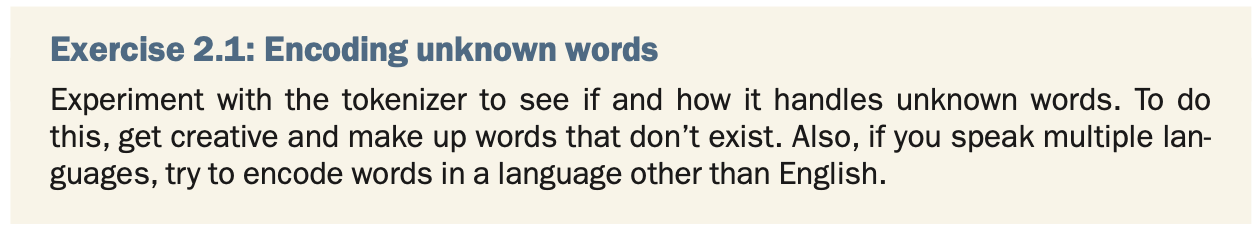


In [36]:
prompt = " ma numesc das2a22sa2321321313 edsdasd9asd9a988989 8yapt3r3"
input_token_ids_list = tokenizer.encode(prompt)

for i in input_token_ids_list:
    print(f"{i} --> {tokenizer.decode([i])}")

7491 -->  ma
1629 -->  num
3300 --> esc
6616 -->  das
17 --> 2
64 --> a
17 --> 2
17 --> 2
9081 --> sa
17 --> 2
18 --> 3
17 --> 2
16 --> 1
18 --> 3
17 --> 2
16 --> 1
18 --> 3
16 --> 1
18 --> 3
1578 -->  ed
13446 --> sd
79102 --> asd
24 --> 9
79102 --> asd
24 --> 9
64 --> a
24 --> 9
23 --> 8
23 --> 8
24 --> 9
23 --> 8
24 --> 9
220 -->  
23 --> 8
88 --> y
2689 --> apt
18 --> 3
81 --> r
18 --> 3


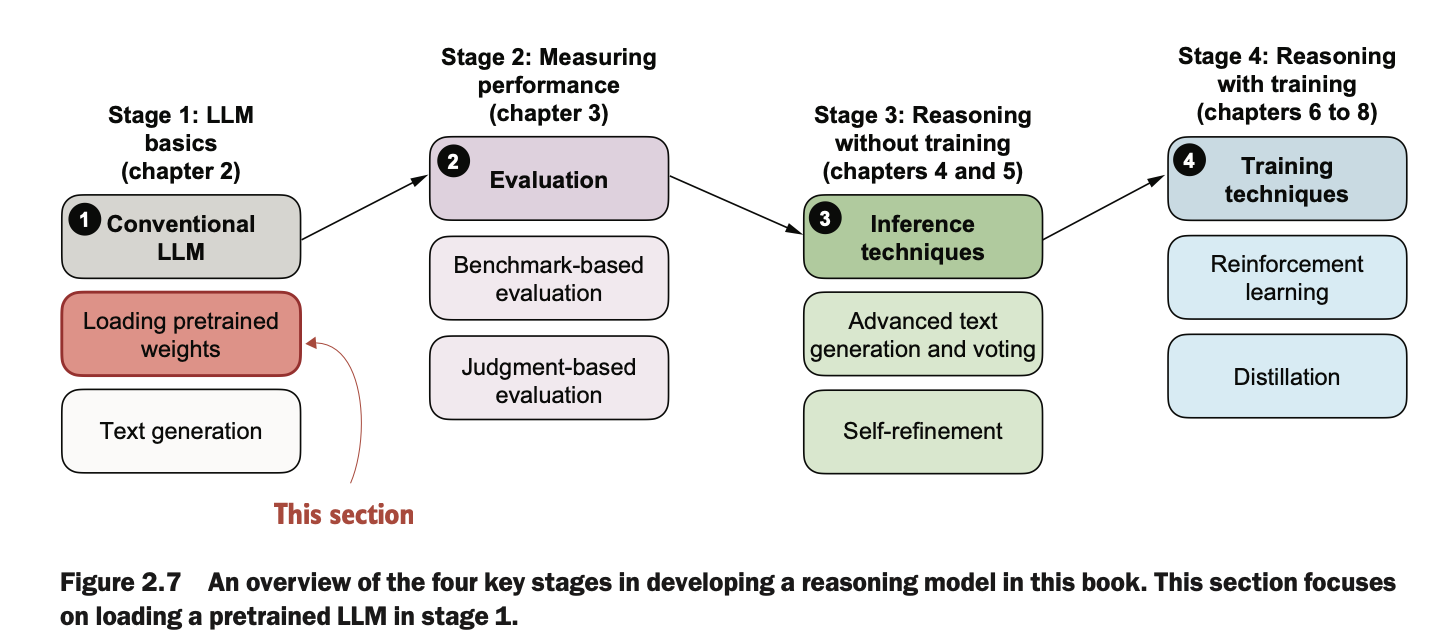


In [37]:
import torch


def get_device(enable_tensor_cores=True):
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using NVIDIA CUDA GPU")

        if enable_tensor_cores:
            major, minor = map(int, torch.__version__.split(".")[:2])
            # PyTorch 2.9 and 2.10 still read the legacy TF32 setting in torch.compile.
            # See https://github.com/pytorch/pytorch/issues/166387
            # and https://github.com/rasbt/reasoning-from-scratch/issues/256
            if (major, minor) >= (2, 11):
                torch.backends.cuda.matmul.fp32_precision = "tf32"
                torch.backends.cudnn.conv.fp32_precision = "tf32"  # type: ignore
            else:
                torch.backends.cuda.matmul.allow_tf32 = True
                torch.backends.cudnn.allow_tf32 = True

    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU (MPS)")

    elif torch.xpu.is_available():
        device = torch.device("xpu")
        print("Using Intel GPU")

    return device


device = get_device()

Using Apple Silicon GPU (MPS)


In [38]:
# Download the model weights :

download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")

✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [39]:
#  instantiate a Qwen3Model class
#  and load the pretrained weights via PyTorch’s load_state_dict method:

from reasoning_from_scratch.qwen3 import Qwen3Model, QWEN_CONFIG_06_B

model_path = Path("qwen3") / "qwen3-0.6B-base.pth"

model = Qwen3Model(QWEN_CONFIG_06_B)
model.load_state_dict(torch.load(model_path))

model.to(device)

Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

# Qwen3 architecture :

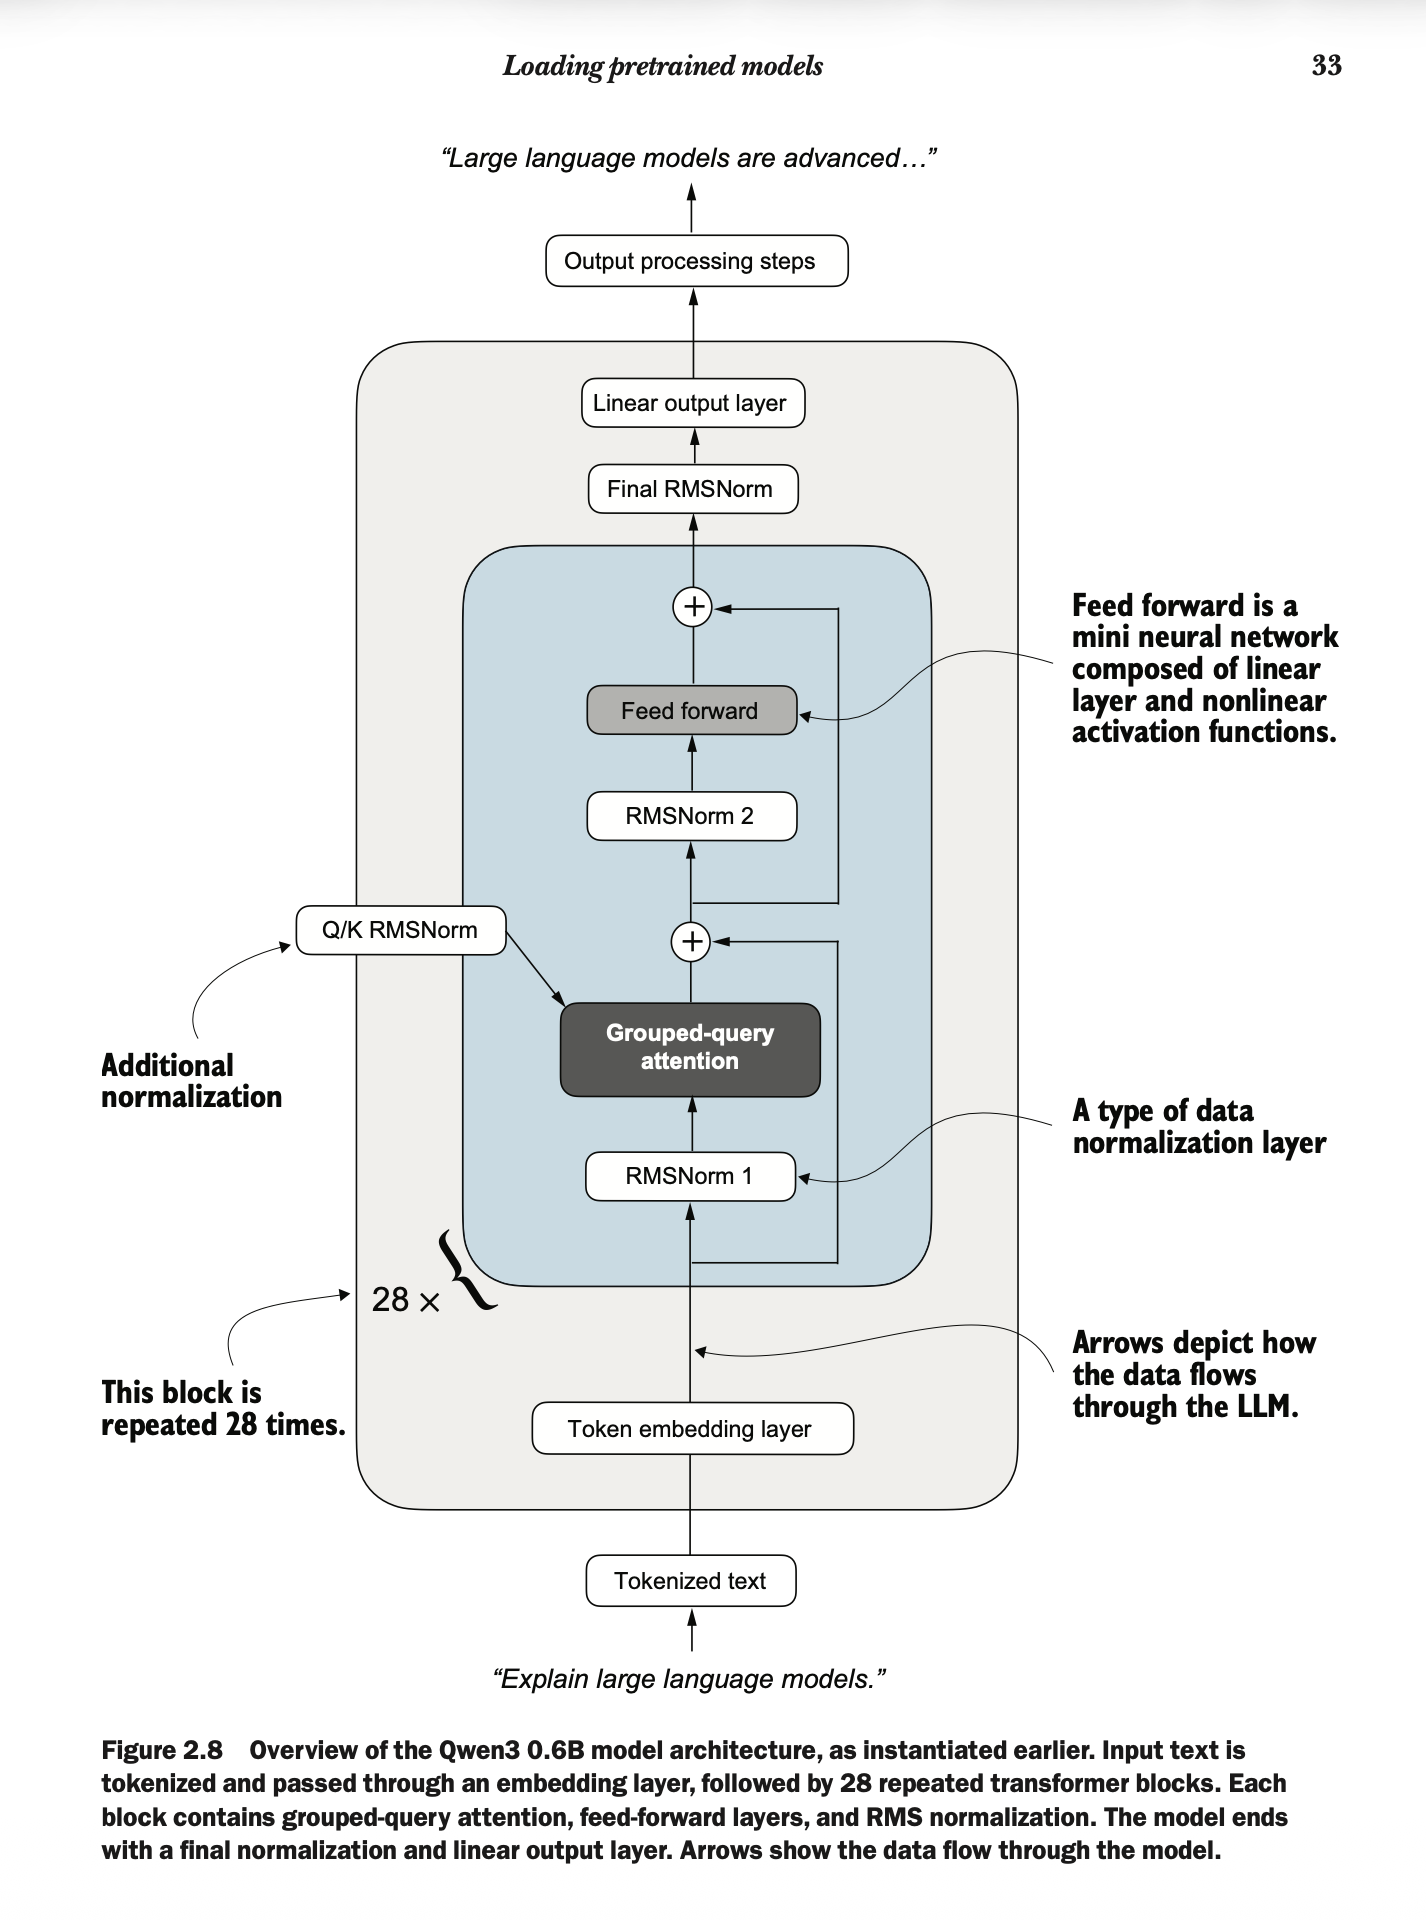


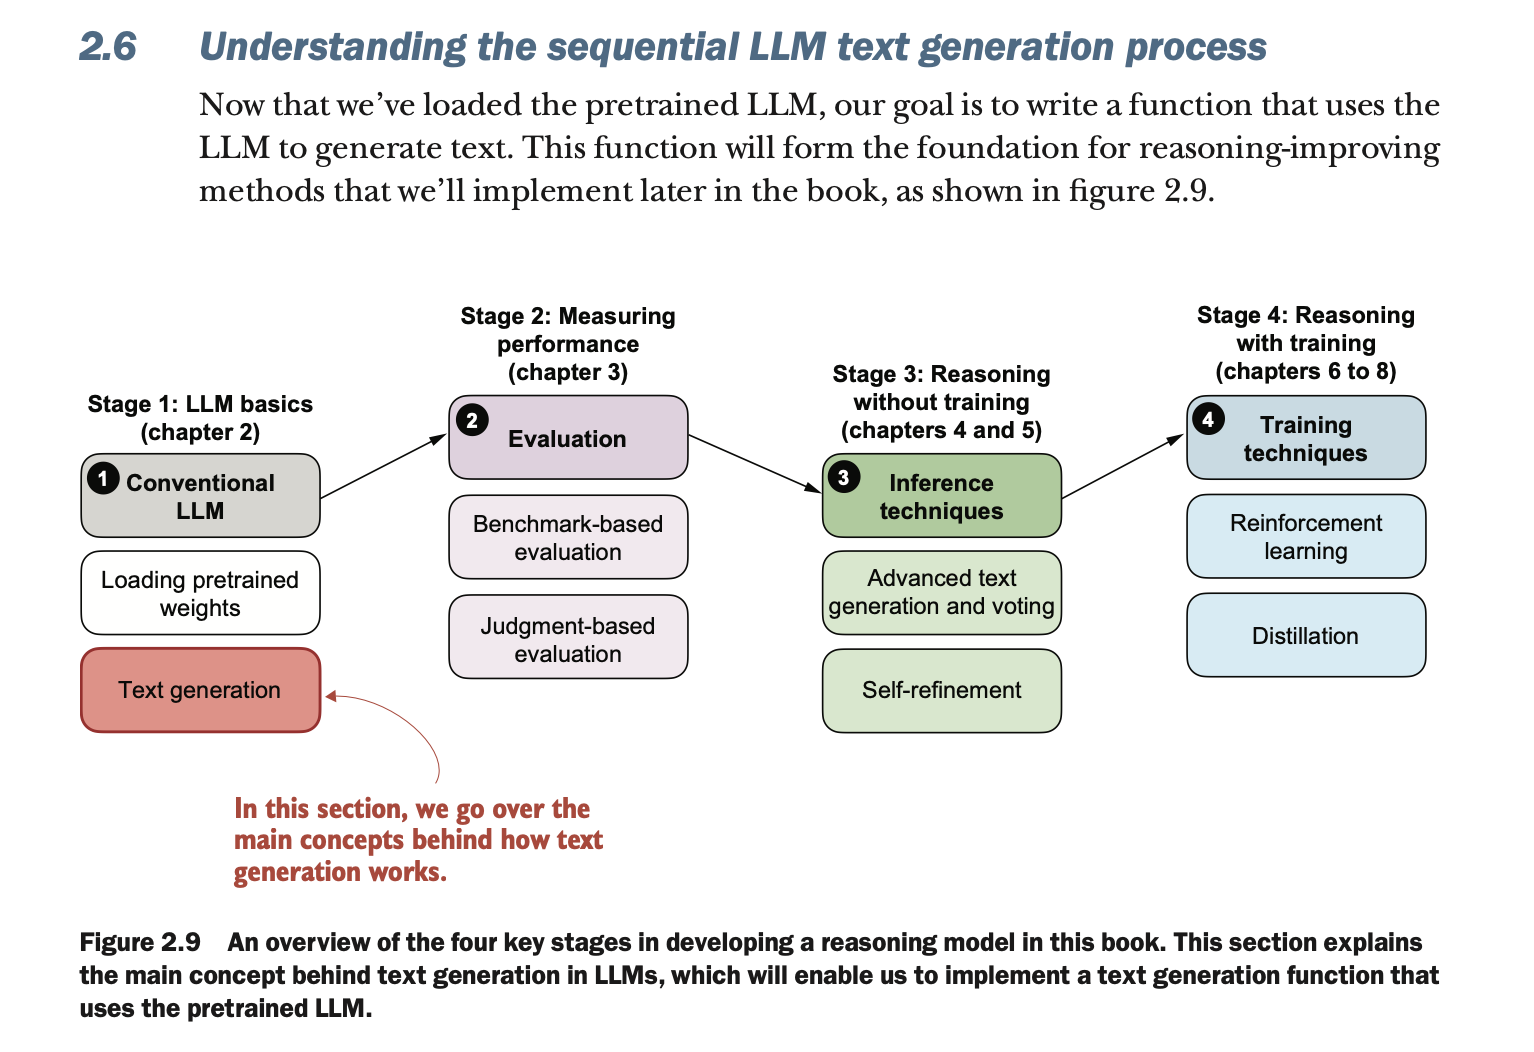


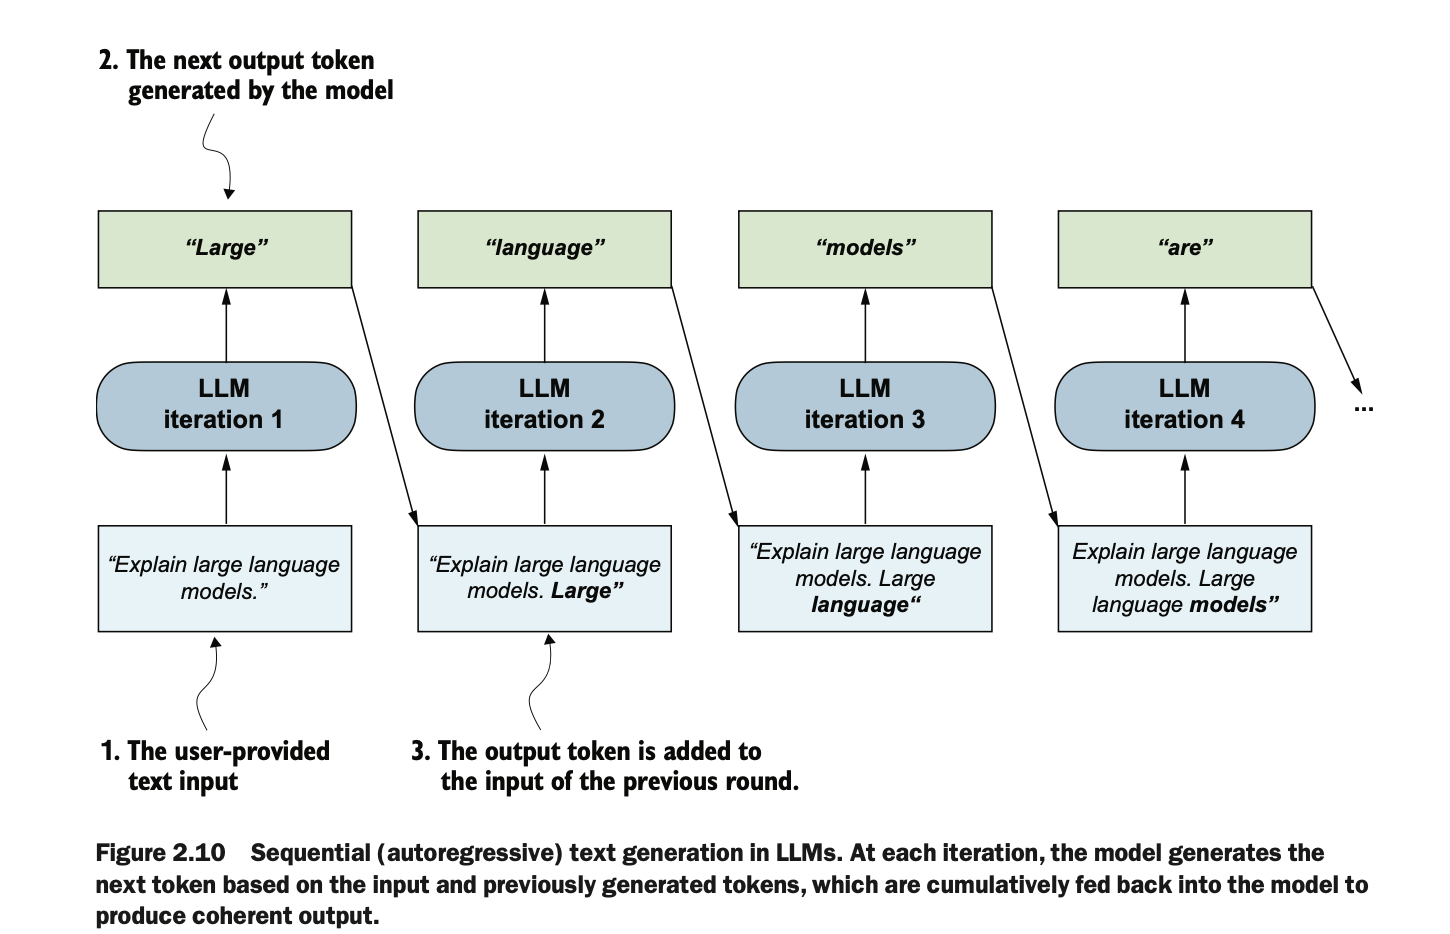


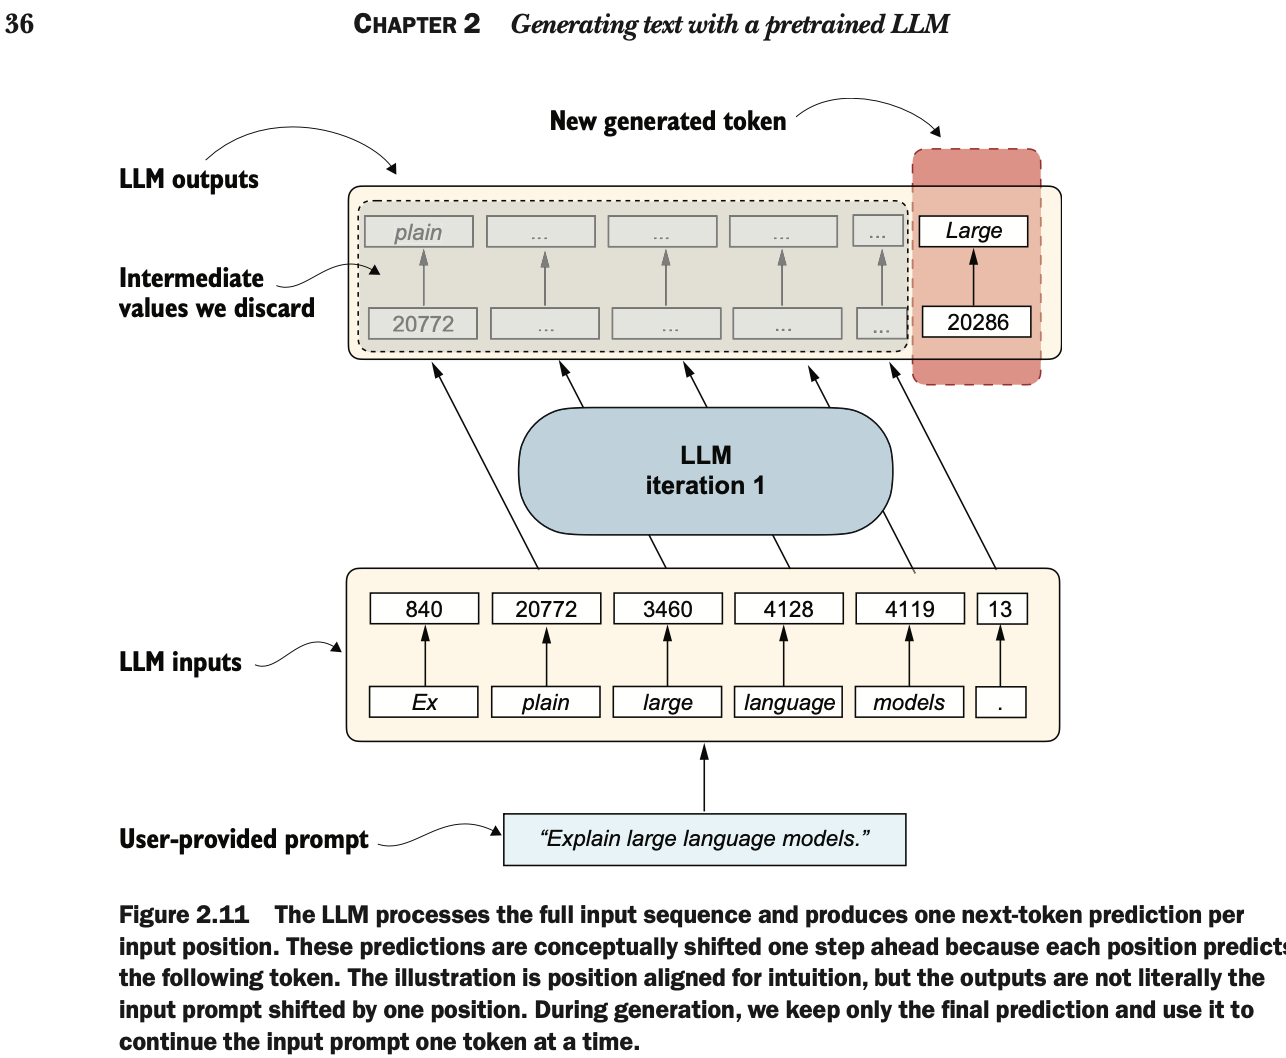


In [40]:
prompt = "Explain large language models."
input_token_ids_list = tokenizer.encode(prompt)
print(f"Number of input tokens: {len(input_token_ids_list)}")

input_tensor = torch.tensor(input_token_ids_list)  # Add an additional dimension.
input_tensor_fmt = input_tensor.unsqueeze(0).to(device)

with torch.inference_mode():
    output_tensor = model(input_tensor_fmt)  # Generate the output.

output_tensor_fmt = output_tensor.squeeze(0)  # Remove the extra dimension.
print(f"Formatted Output tensor shape: {output_tensor_fmt.shape}")

Number of input tokens: 6
Formatted Output tensor shape: torch.Size([6, 151936])


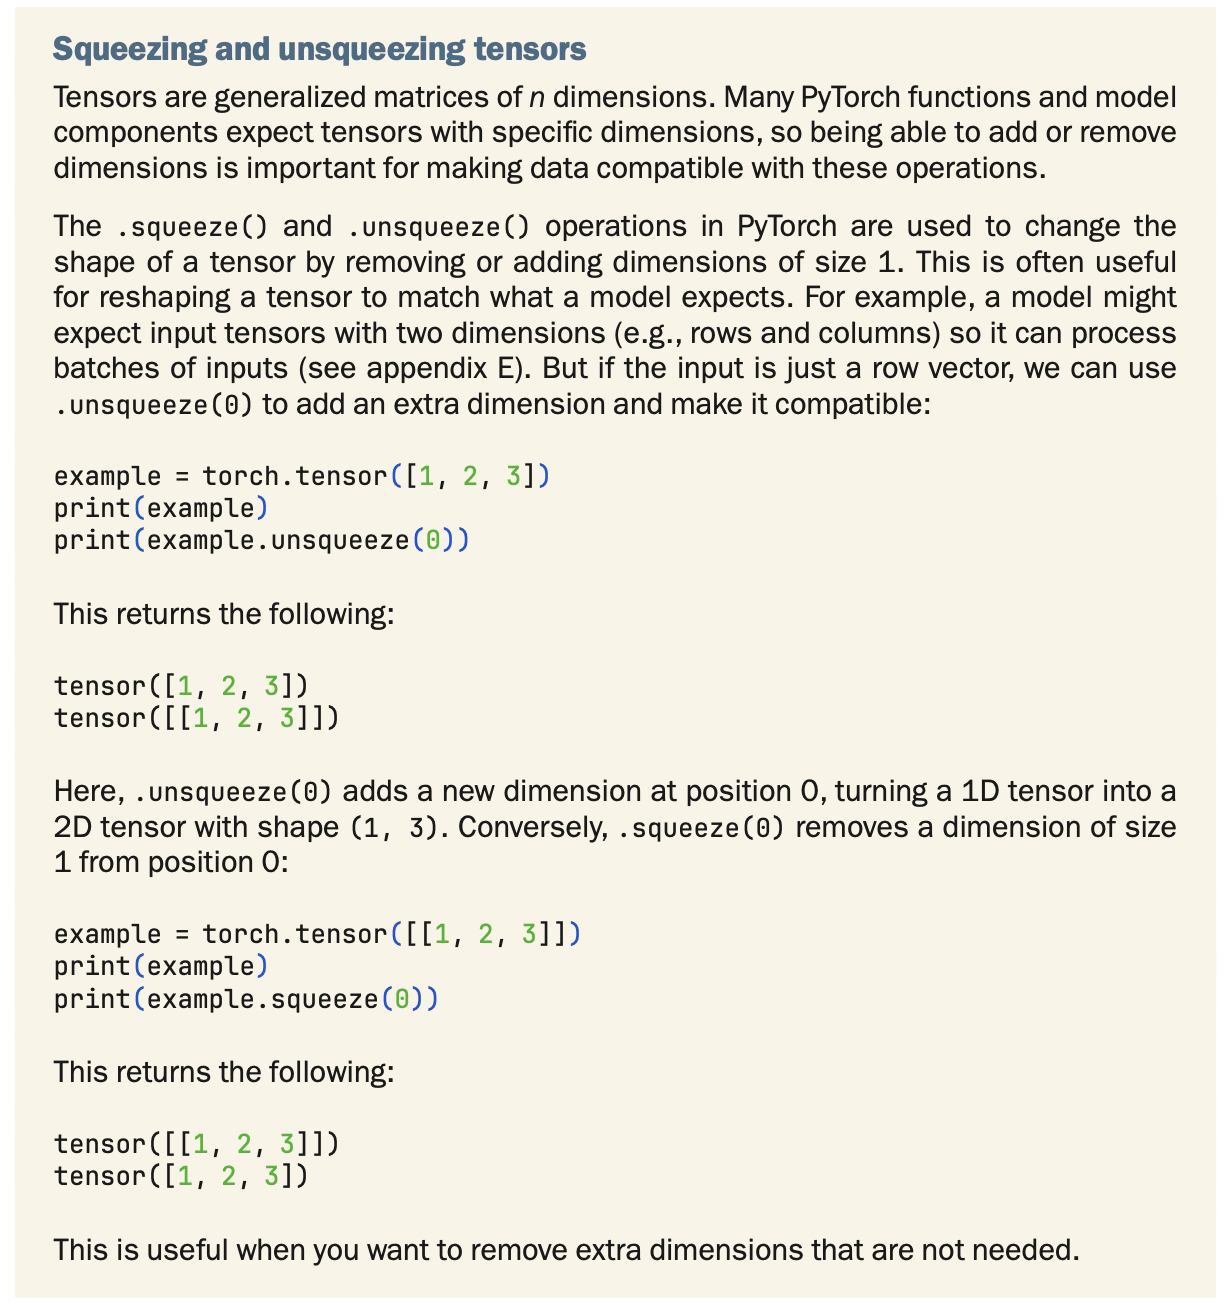


In [41]:
example = torch.tensor([1, 2, 3])
print(example)
print(example.unsqueeze(0))

example = torch.tensor([[1, 2, 3]])
print("\n", example)
print(example.squeeze(0))

tensor([1, 2, 3])
tensor([[1, 2, 3]])

 tensor([[1, 2, 3]])
tensor([1, 2, 3])


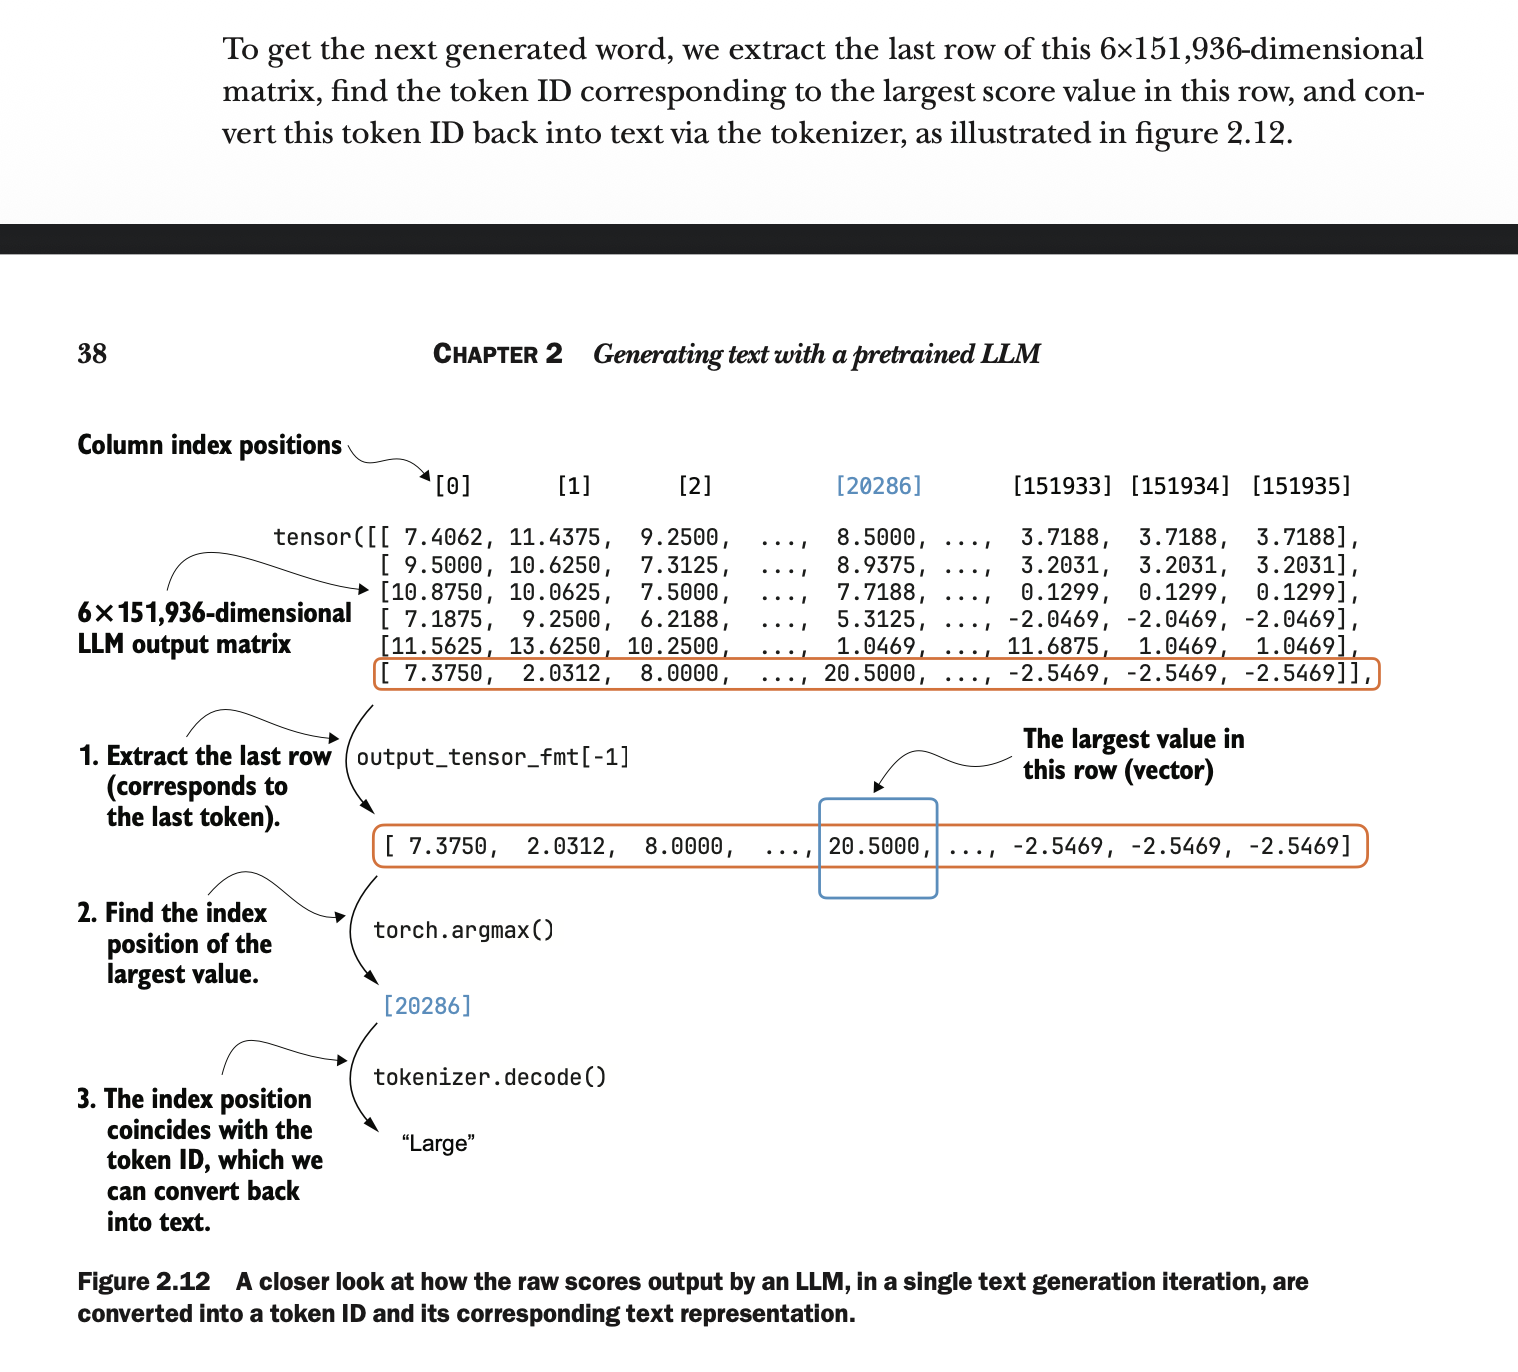


In [42]:
last_token = output_tensor_fmt[-1]
print(last_token)

tensor([ 7.3438,  2.0312,  7.9375,  ..., -2.5156, -2.5156, -2.5156],
       device='mps:0', dtype=torch.bfloat16)


In [43]:
# Then, we can use the argmax function to obtain the position
# with the largest value score (value) in this tensor:

print(torch.argmax(last_token, dim=-1, keepdim=True))

print(tokenizer.decode([20286]))

tensor([20286], device='mps:0')
 Large


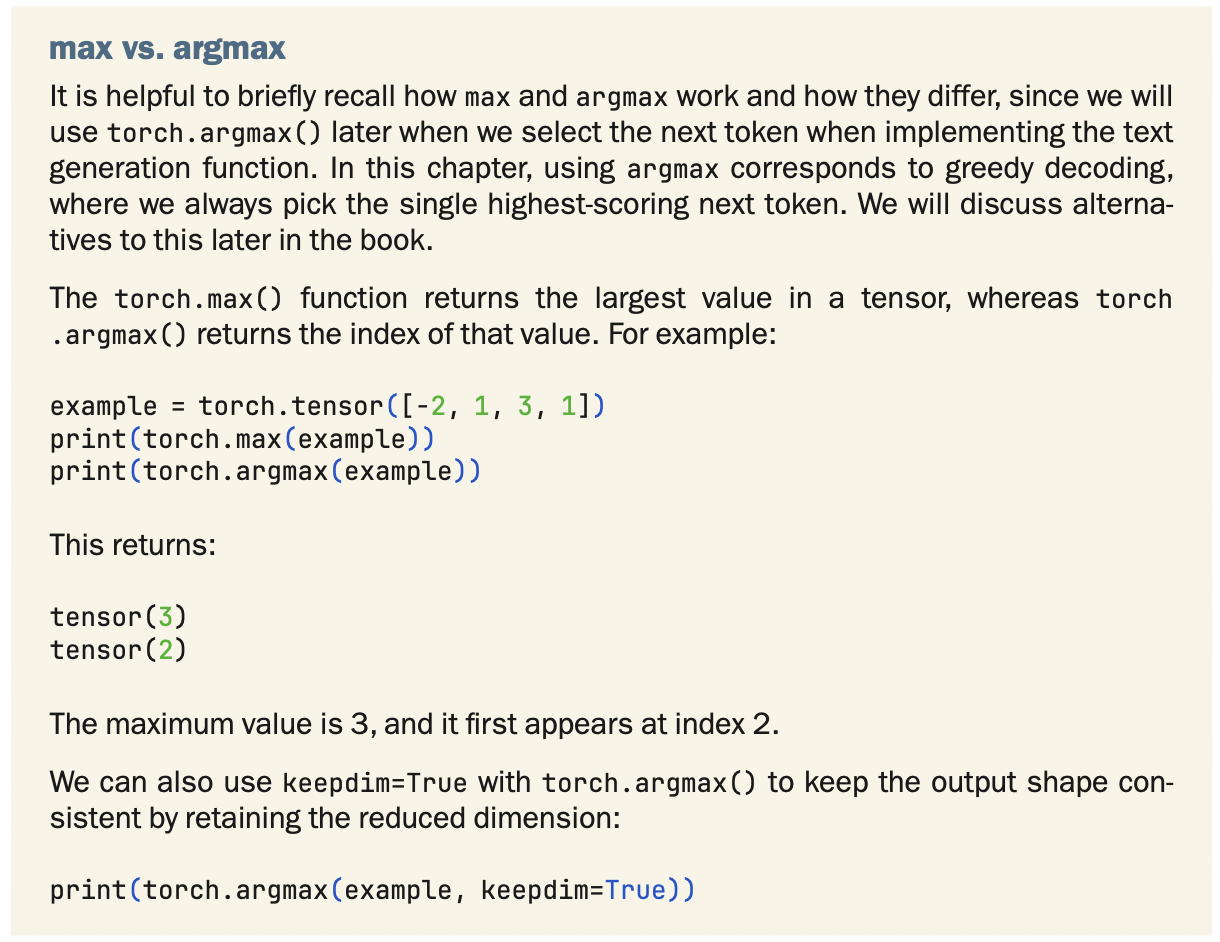


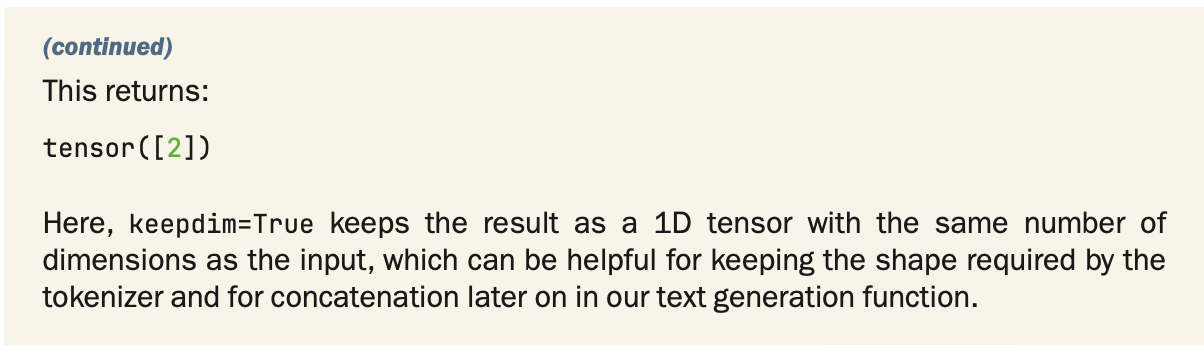


In [44]:
example = torch.tensor([-2, 1, 3, 1])
print(torch.max(example))
print(torch.argmax(example))

# We can also use keepdim=True with torch.argmax() to keep the output shape
# consistent by retaining the reduced dimension:

print(torch.argmax(example, keepdim=True))

tensor(3)
tensor(2)
tensor([2])


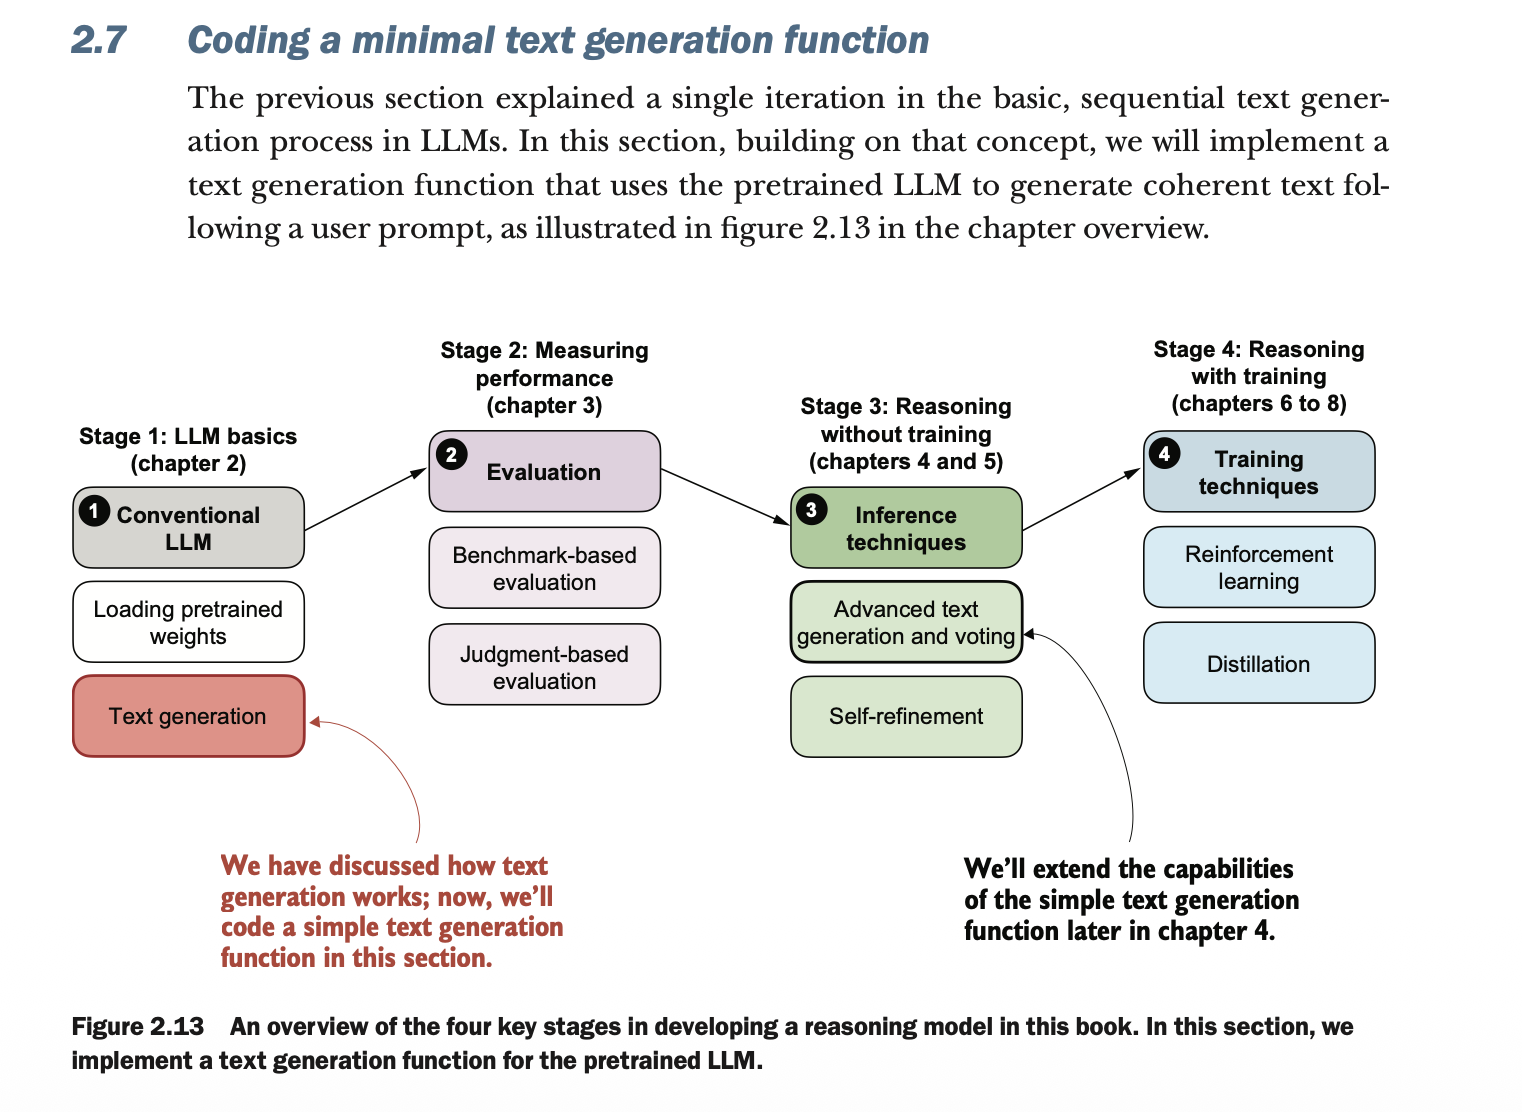


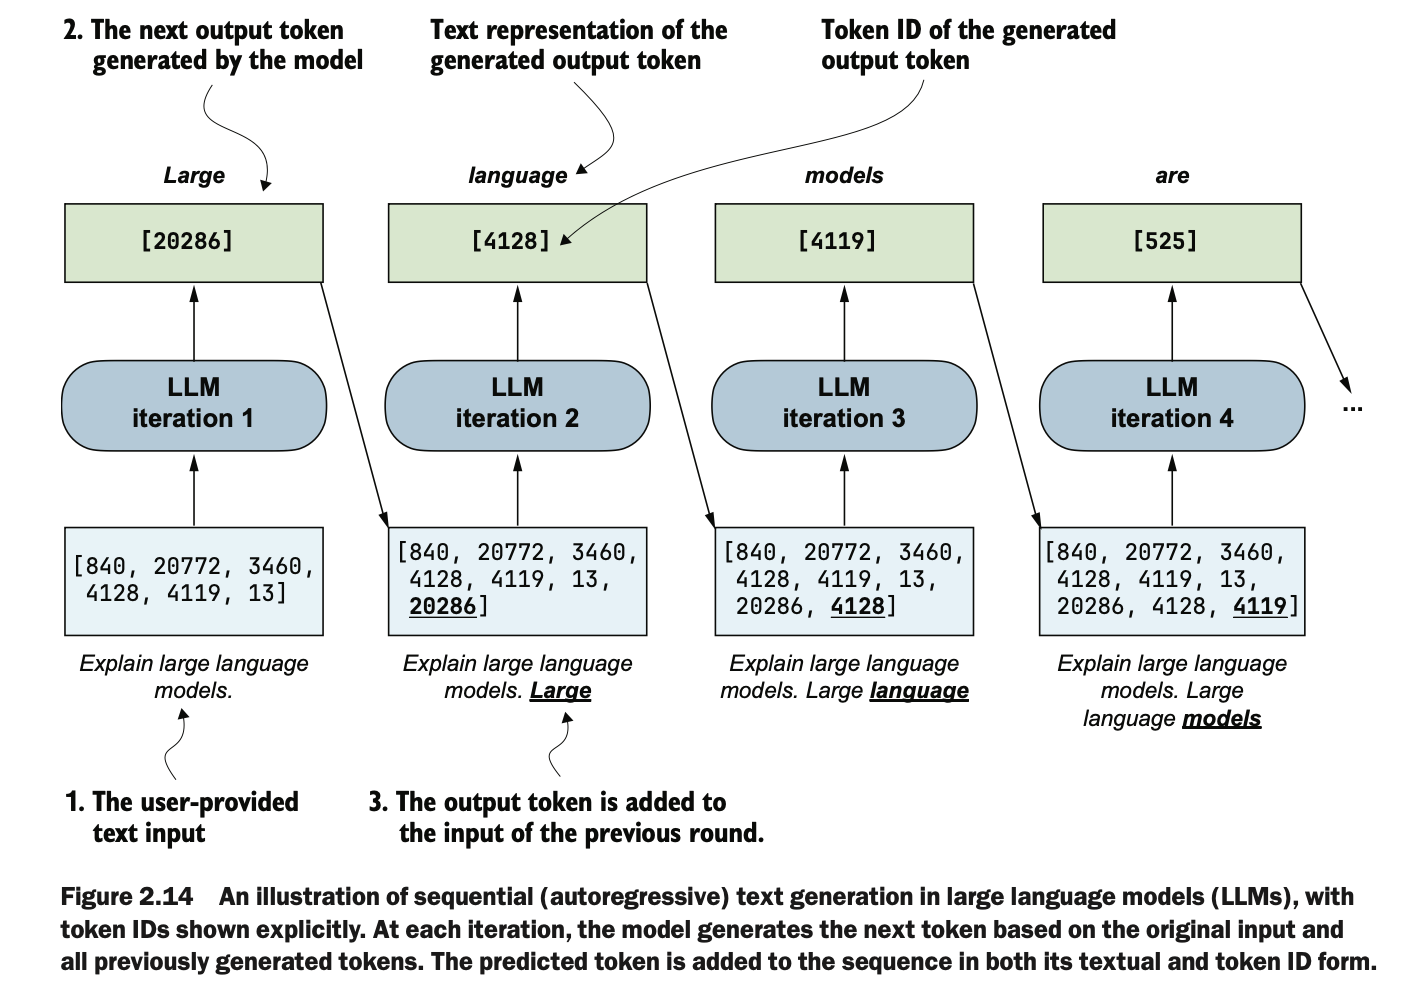


In [45]:
# Disable gradient tracking for speed and memory efficiency.
@torch.inference_mode()
def generate_text_basic_stream(model, token_ids, max_new_tokens, eos_token_id=None):

    #     Switch model to evaluation mode to enable
    # deterministic behavior (best practice).
    model.eval()

    for _ in range(max_new_tokens):
        out = model(token_ids)[:, -1]  # get the scores of last token
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        # Stop if all sequences in the batch have generated EOS :
        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token  # Yield each token as soon as it’s generated.

        token_ids = torch.cat(
            [token_ids, next_token], dim=1
        )  # Append the newly predicted token to the sequence.

In [46]:
prompt = "Explain large language models in a single sentence."

input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt),
    device=device,  # Transfer the input token IDs onto the same device (CPU, GPU) where the model is located.
).unsqueeze(0)
max_new_tokens = 100  # let model generate up to 100 tokens

for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
):
    # Convert output token IDs from PyTorch tensor to Python list.
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True,  # Deactivates buffering so tokens are printed live
    )

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.<|endoftext|>Human language is a complex and dynamic system that has evolved over millions of years to enable effective communication and social interaction. It is composed of a vast array of symbols, including letters, numbers, and words, which are used to convey meaning and express thoughts and ideas. The structure of human language

In [47]:
print(tokenizer.encode("<|endoftext|>"))

[151643]


In [48]:
for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
    eos_token_id=tokenizer.eos_token_id,  # Pass end-of-sequence (eos) token ID.
):
    token_id = token.squeeze(0).tolist()
    print(tokenizer.decode(token_id), end="", flush=True)

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

# Listing 2.3 Token generation speed and memory usage

- Before we wrap up this section and see how we can speed up the code, let's implement a simple benchmarking function to track the computational performance


In [49]:
import warnings


def generate_stats(output_token_ids, tokenizer, start_time, end_time):
    total_time = end_time - start_time
    print(f"\n\nTime: {total_time:.2f} sec")
    print(f"{int(output_token_ids.numel() / total_time)} tokens/sec")

    for name, backend in (
        ("CUDA", getattr(torch, "cuda", None)),
        ("XPU", getattr(torch, "xpu", None)),
    ):
        if backend is not None and backend.is_available():

            # Check whether we are actually using this backend
            device_type = output_token_ids.device.type
            if device_type != name.lower():
                warnings.warn(
                    f"{name} is available but tensors are on "
                    f"{device_type}. Memory stats may be 0."
                )

            # Synchronize if supported (important for async backends)
            if hasattr(backend, "synchronize"):
                backend.synchronize()

            max_mem_bytes = backend.max_memory_allocated()
            max_mem_gb = max_mem_bytes / (1024**3)
            print(f"Max {name} memory allocated: {max_mem_gb:.2f} GB")
            backend.reset_peak_memory_stats()

In [50]:
import time

start_time = time.time()
generated_ids = []

for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
    eos_token_id=tokenizer.eos_token_id,
):
    token_id = token.squeeze(0).tolist()
    print(tokenizer.decode(token_id), end="", flush=True)

    next_token_id = token.squeeze(0)
    generated_ids.append(next_token_id)  # Collect generated tokens

end_time = time.time()

output_token_ids_tensor = torch.cat(generated_ids, dim=0)
generate_stats(output_token_ids_tensor, tokenizer, start_time, end_time)

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Time: 2.30 sec
17 tokens/sec


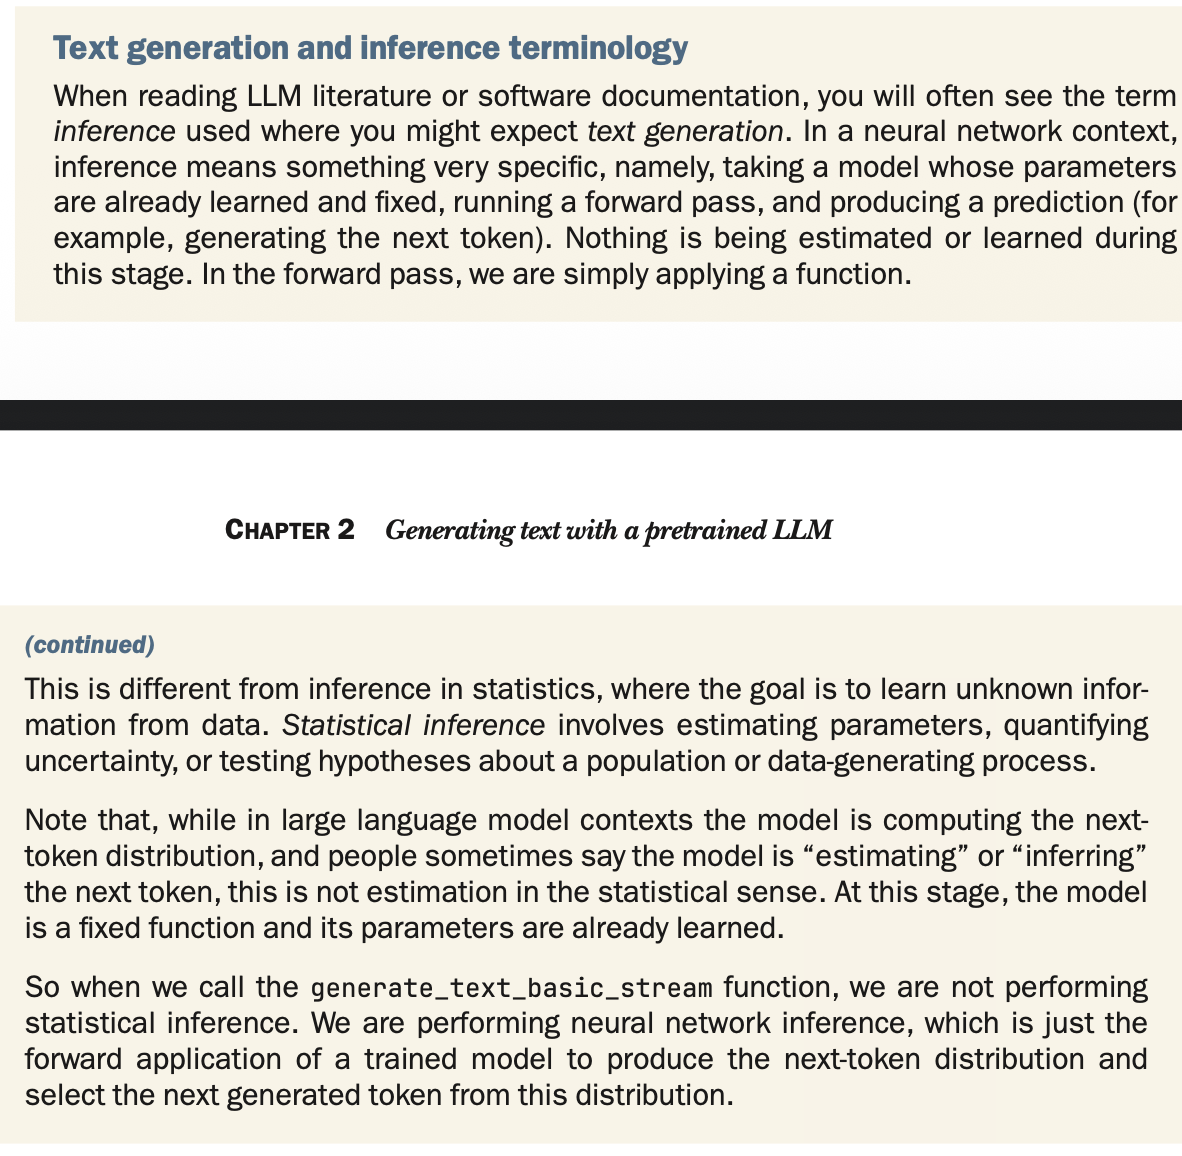


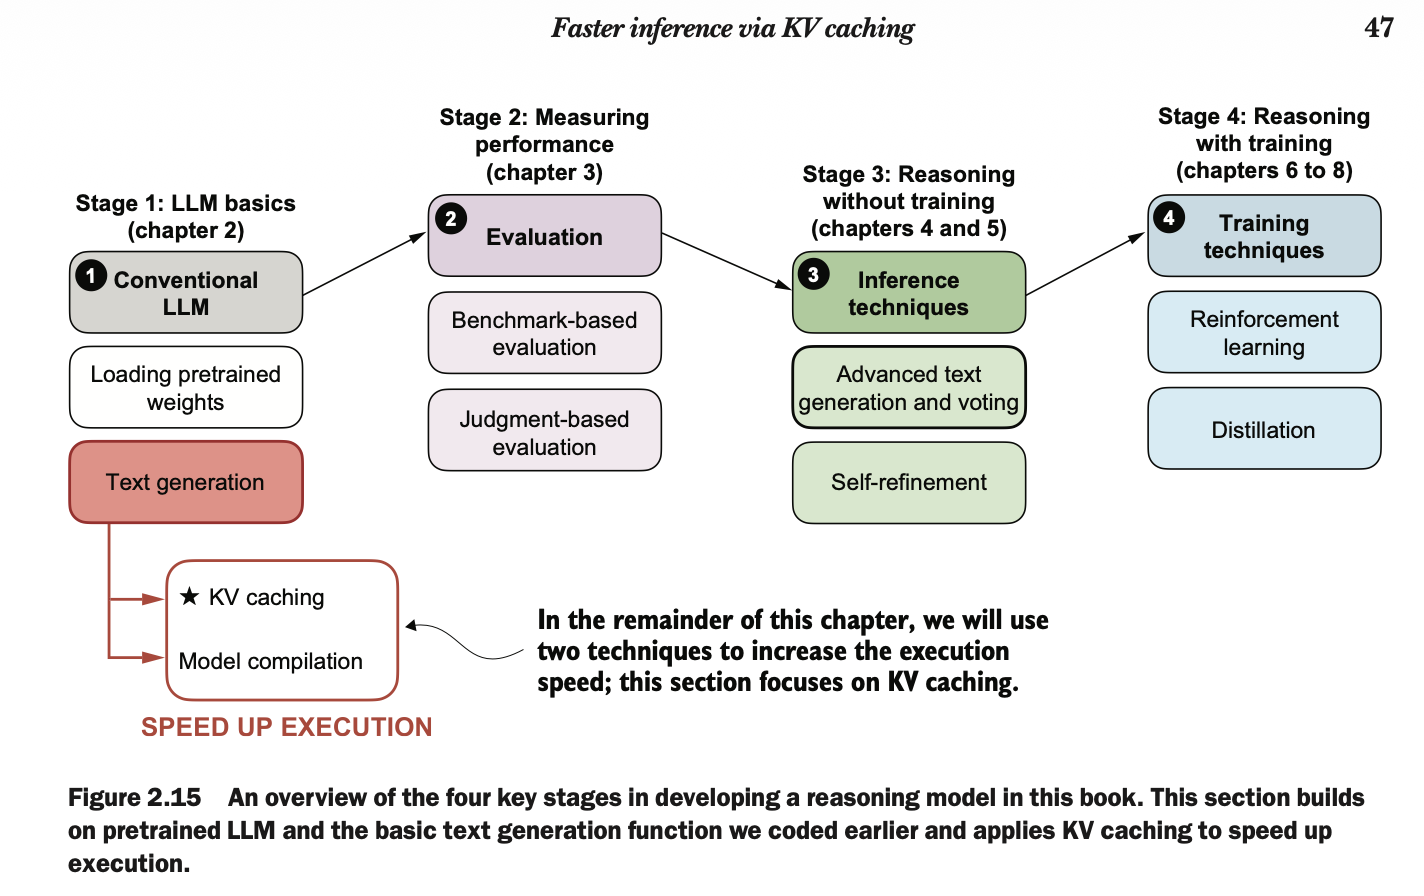
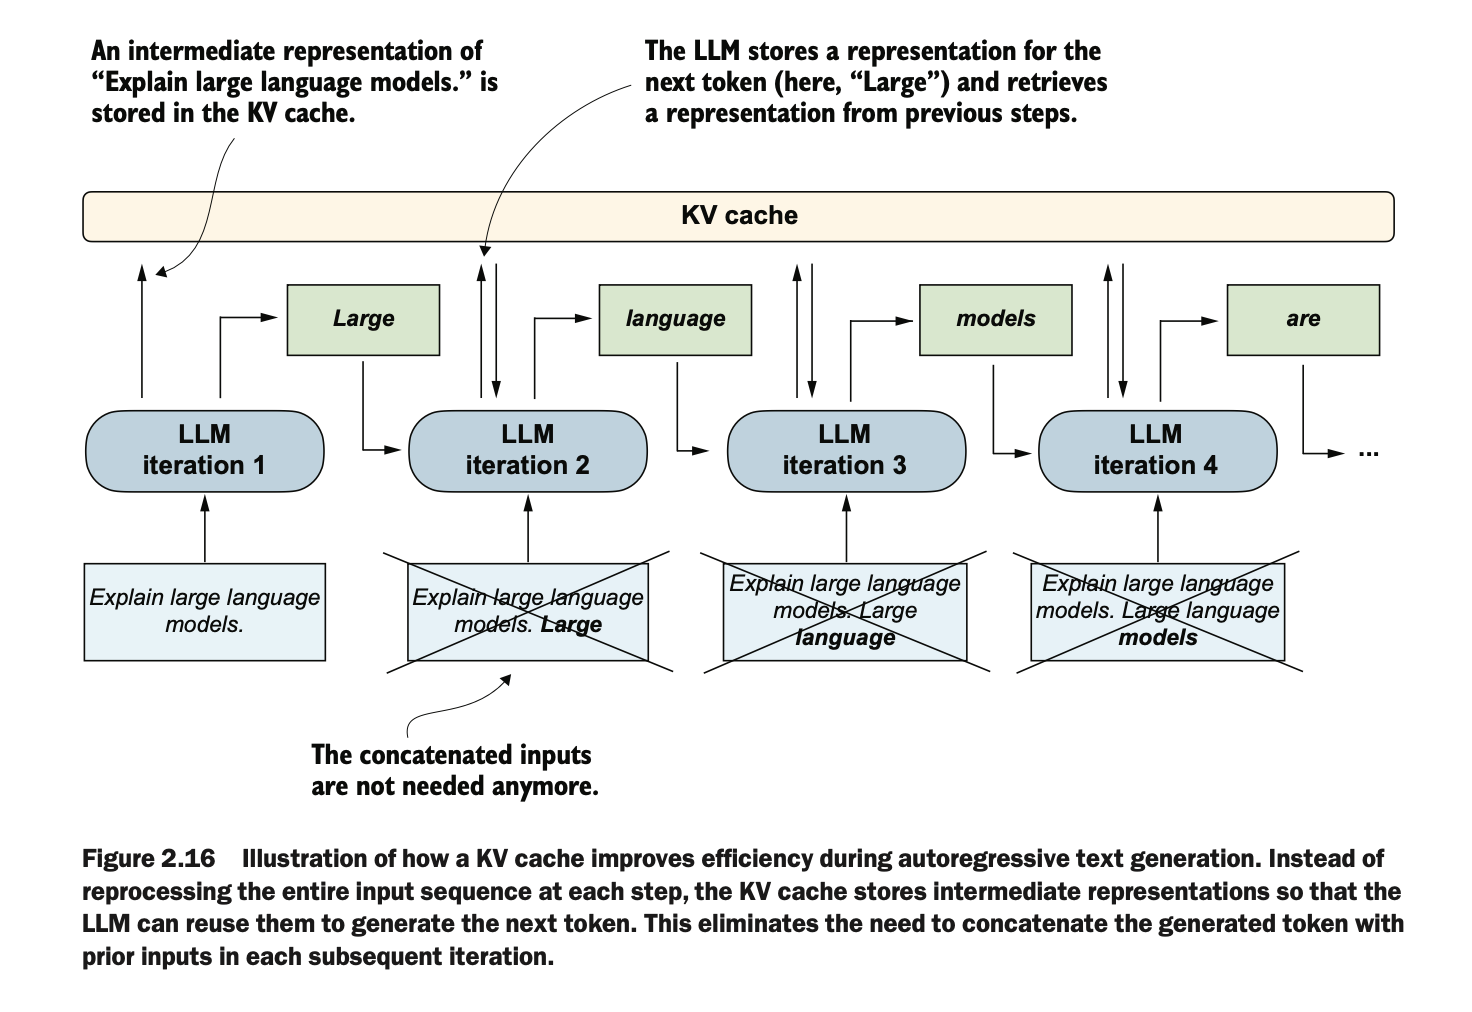


In [51]:
# Listing 2.4 A basic text generation function with KV cache
from reasoning_from_scratch.qwen3 import KVCache


@torch.inference_mode()
def generate_text_basic_stream_cache(
    model, token_ids, max_new_tokens, eos_token_id=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])  # Init Kv_Cache
    model.reset_kv_cache()  # New

    # In the first round, the whole input is provided to the model as before.
    out = model(token_ids, cache=cache)[:, -1]

    for _ in range(max_new_tokens):
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token

        # Consequent iterations only feed the next_token to the input.
        out = model(next_token, cache=cache)[:, -1]

In [52]:
start_time = time.time()
generated_ids = []

for token in generate_text_basic_stream_cache(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
    eos_token_id=tokenizer.eos_token_id,
):
    token_id = token.squeeze(0).tolist()
    print(tokenizer.decode(token_id), end="", flush=True)

    next_token_id = token.squeeze(0)
    generated_ids.append(next_token_id)  # Collect generated tokens

end_time = time.time()

output_token_ids_tensor = torch.cat(generated_ids, dim=0)
generate_stats(output_token_ids_tensor, tokenizer, start_time, end_time)

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Time: 1.84 sec
22 tokens/sec


## 2.9 Faster inference via PyTorch model compilation

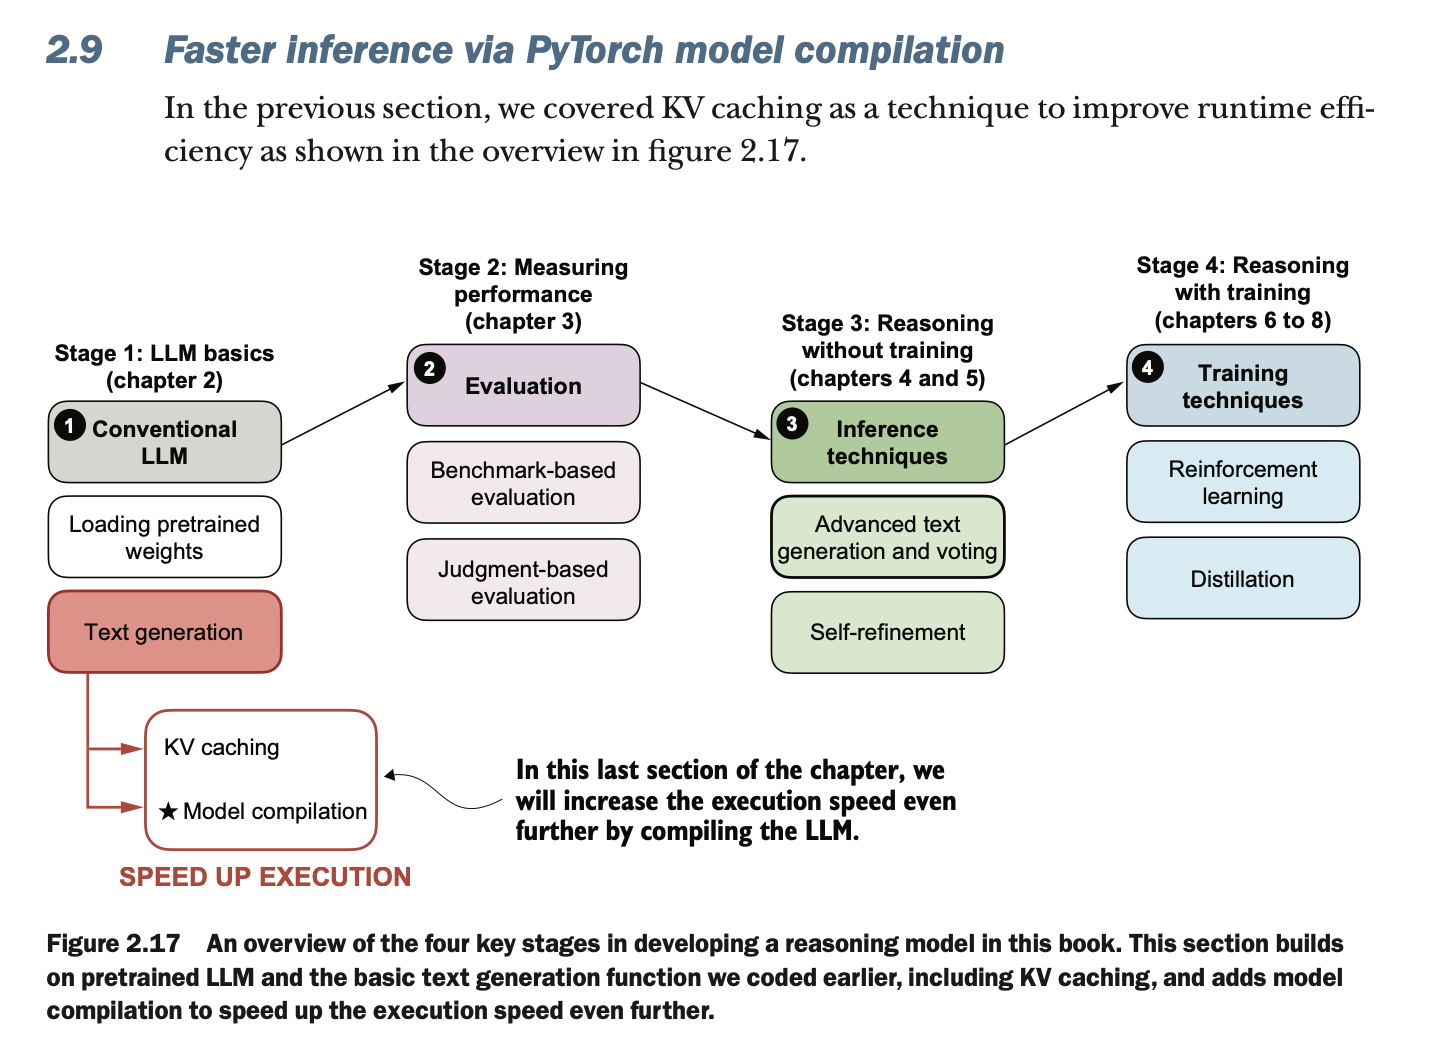


In [53]:
major, minor = map(int, torch.__version__.split(".")[:2])
if (major, minor) >= (2, 8):
    # This avoids retriggering model recompilations
    # in PyTorch 2.8 and newer
    # if the model contains code like self.pos = self.pos + 1
    torch._dynamo.config.allow_unspec_int_on_nn_module = True

model_compiled = torch.compile(model)

# If you have issues with torch.compile on "mps" devices and get an InductorError,
# make sure you are using PyTorch 2.9 or newer

- The first iteration can be a bit slow as it does the initial compilation and optimization; hence, we repeat the text generation multiple times

- First, let's start with the non-cached version (this can be a bit slow and might take xx minutes)


In [54]:
for i in range(3):

    start_time = time.time()
    generated_ids = []

    for token in generate_text_basic_stream(
        model=model_compiled,
        token_ids=input_token_ids_tensor,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    ):
        token_id = token.squeeze(0).tolist()
        print(tokenizer.decode(token_id), end="", flush=True)

        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id)  # Collect generated tokens

    end_time = time.time()

    if i == 0:
        print("\n\nWarm-up run")
    else:
        print(f"\n\nTimed run {i}:")

    output_token_ids_tensor = torch.cat(generated_ids, dim=0)
    generate_stats(output_token_ids_tensor, tokenizer, start_time, end_time)

    print(f"\n{30*'-'}\n")

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing essays, and even creating creative content.

Warm-up run


Time: 1.44 sec
28 tokens/sec

------------------------------

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing essays, and even creating creative content.

Timed run 1:


Time: 1.44 sec
28 tokens/sec

------------------------------

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing essays, and even creating creative content.

Timed run 2:


Time: 1.47 sec
27 tokens/sec

------------------------------



- Let's now see how well the KV cache version does :


In [55]:
for i in range(3):

    start_time = time.time()
    generated_ids = []

    for token in generate_text_basic_stream_cache(
        model=model_compiled,
        token_ids=input_token_ids_tensor,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    ):
        token_id = token.squeeze(0).tolist()
        print(tokenizer.decode(token_id), end="", flush=True)

        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id)  # Collect generated tokens

    end_time = time.time()

    if i == 0:
        print("\n\nWarm-up run")
    else:
        print(f"\n\nTimed run {i}:")

    output_token_ids_tensor = torch.cat(generated_ids, dim=0)
    generate_stats(output_token_ids_tensor, tokenizer, start_time, end_time)

    print(f"\n{30*'-'}\n")

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Warm-up run


Time: 0.91 sec
44 tokens/sec

------------------------------

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Timed run 1:


Time: 0.88 sec
46 tokens/sec

------------------------------

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing articles, and even creating creative content.

Timed run 2:


Time: 0.83 sec
49 tokens/sec

------------------------------

